# Toy models, MCMC, and when inference falls apart

**Day 2, 14:30–15:30 — 60 minutes.** Alexander Fengler.

Two halves, one idea.

- **Half A (14:30).** Samplers on a posterior we know exactly. What makes a
  posterior hard, and what different samplers do about it.
- **Half B (15:00).** The same lesson on a real cognitive model — where the
  difficulty is created not by the sampler but by the **experiment design**.

The thread running through both: *a posterior can be perfectly well-defined
and still be badly conditioned*, and badly conditioned posteriors break
samplers in ways that are easy to miss and easy to misdiagnose.

In [1]:
import sys, pathlib, time, warnings
sys.path.insert(0, str(pathlib.Path.cwd().parent))  # -> tutorials/

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import sbi4cogsci_style as S

S.use()
warnings.filterwarnings("ignore")

RANDOM_SEED = sum(map(ord, "sbi4cogsci-mcmc"))
rng = np.random.default_rng(RANDOM_SEED)

# Sampling budgets. Kept modest so the whole notebook re-runs in a few minutes;
# raise them if you want tighter estimates.
DRAWS, TUNE, CHAINS = 1000, 1000, 4      # the main DDM fits
DRAWS_CMP, TUNE_CMP = 1500, 1000         # the sampler comparison in B.4

print("pymc", pm.__version__, "| arviz", az.__version__)

pymc 6.2.0 | arviz 1.2.0


## Half A — samplers on a posterior we can check

### A.1 A target with no unknowns

We use a bivariate normal with correlation $\rho$, written so that each
variable is its own node:

$$x \sim \mathcal{N}(0, 1), \qquad y \mid x \sim \mathcal{N}(\rho x, \sqrt{1-\rho^2})$$

The marginals are both standard normal and $\mathrm{corr}(x,y) = \rho$ — we
know every answer in advance, so any disagreement is the sampler's fault, not
the model's.

Writing it as two scalar nodes rather than one 2-vector matters: PyMC then
assigns a **separate step method to each**, so Metropolis updates one
coordinate at a time. That is the axis-aligned behaviour we want to expose.

In [2]:
def correlated_gaussian(rho):
    with pm.Model() as model:
        x = pm.Normal("x", 0.0, 1.0)
        pm.Normal("y", rho * x, np.sqrt(1.0 - rho**2))
    return model


def autocorr(posterior, var="x"):
    """Autocorrelation function of a posterior variable, via ArviZ.

    In ArviZ 1.x the numeric ACF lives on the `.azstats` accessor rather than as
    a top-level `az.autocorr` function — this is exactly what `az.plot_autocorr`
    calls internally. Returns lags along the `draw` dimension.
    """
    return posterior[var].azstats.autocorr(dim=("chain", "draw"))


SAMPLERS = {
    "Metropolis": (lambda: pm.Metropolis(), S.NAIVE),
    "Slice": (lambda: pm.Slice(), S.ALT),
    "NUTS": (None, S.PRIMARY),
}


def run(rho, sampler_name, draws=4000, tune=1000, seed=RANDOM_SEED):
    step_factory, _ = SAMPLERS[sampler_name]
    with correlated_gaussian(rho):
        kw = dict(draws=draws, tune=tune, chains=2, cores=1,
                  progressbar=False, random_seed=seed)
        t0 = time.time()
        if step_factory is None:
            # Ask for PyMC's own NUTS explicitly. With nuts_sampler unset,
            # pm.sample() silently prefers nutpie when it is installed, and you
            # would be timing a different implementation than you think.
            idata = pm.sample(nuts_sampler="pymc", **kw)
        else:
            idata = pm.sample(step=step_factory(), **kw)
        wall = time.time() - t0
    post = idata.posterior.dataset            # DataTree node -> Dataset
    return idata, post, wall

### A.2 Predict before you run

For an **exact Gibbs** sampler on this target — one that draws each coordinate
from its exact conditional — the lag-1 autocorrelation is exactly $\rho^2$.
Under the usual geometric-decay approximation that gives

$$\frac{\mathrm{ESS}}{N} \approx \frac{1-\rho^2}{1+\rho^2}$$

So at $\rho = 0.99$ exact Gibbs keeps roughly **1%** of its draws.

Treat that as a **benchmark, not a prediction for Metropolis**. Exact Gibbs is
the best an axis-aligned method can do, because it makes the largest possible
move along each axis. PyMC's `Metropolis` random-walks *within* each
conditional instead of sampling it, so it should come out **worse** than the
line. Slice sampling, which does carve out a genuine interval along the axis,
should land close to it. Watch for that ordering in the table.

In [3]:
for rho in [0.0, 0.9, 0.99]:
    pred = (1 - rho**2) / (1 + rho**2)
    print(f"rho={rho:4.2f}   predicted lag-1 autocorr {rho**2:5.3f}   "
          f"predicted ESS/N {pred:6.3f}")

rho=0.00   predicted lag-1 autocorr 0.000   predicted ESS/N  1.000
rho=0.90   predicted lag-1 autocorr 0.810   predicted ESS/N  0.105
rho=0.99   predicted lag-1 autocorr 0.980   predicted ESS/N  0.010


> **Poll.** At $\rho = 0.99$, which sampler do you expect to have the
> *highest* acceptance rate?
>
> **A.** NUTS — it is the most sophisticated.
> **B.** Metropolis — it will shrink its proposal until almost everything is accepted.
> **C.** Slice — it does not reject at all.
> **D.** They will be about the same.

<details>
<summary>Answer</summary>

**C**, and **B** is the trap worth dwelling on. Slice sampling always returns
a point, so "acceptance" is 100% by construction — and it is still slow here,
because the slice it can carve out along one axis is tiny. Metropolis will
happily tune itself to a high acceptance rate by taking microscopic steps.

**High acceptance is not good news.** It is perfectly compatible with a chain
that has barely moved. This is why we measure ESS, not acceptance.

</details>

### A.3 Run all nine

In [4]:
RHOS = [0.0, 0.9, 0.99]
results = {}
rows = []

for rho in RHOS:
    for name in SAMPLERS:
        idata, post, wall = run(rho, name)
        results[(rho, name)] = post
        x = post["x"].values
        ess = float(az.ess(idata, var_names=["x"]).x)
        n_draws = x.size
        acf = np.asarray(autocorr(post)).mean(axis=0)   # average over chains
        rows.append({
            "rho": rho, "sampler": name,
            "ESS": ess, "ESS/N": ess / n_draws,
            "lag-1": float(acf[1]),
            "sec": wall, "ESS/sec": ess / wall,
            "corr(x,y)": float(np.corrcoef(post["x"].values.ravel(),
                                           post["y"].values.ravel())[0, 1]),
        })

table = pd.DataFrame(rows)
print(table.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

Sequential sampling (2 chains in 1 job)


CompoundStep


>Metropolis: [x]


>Metropolis: [y]


Sampling 2 chains for 1_000 tune and 4_000 draw iterations (2_000 + 8_000 draws total) took 0 seconds.


...

Sequential sampling (2 chains in 1 job)


NUTS: [x, y]


Sampling 2 chains for 1_000 tune and 4_000 draw iterations (2_000 + 8_000 draws total) took 1 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


     rho    sampler      ESS    ESS/N    lag-1      sec   ESS/sec  corr(x,y)
   0.000 Metropolis 1758.473    0.220    0.637    0.582  3021.965      0.013
   0.000      Slice 8343.870    1.043   -0.020    0.318 26264.513     -0.015
   0.000       NUTS 8794.502    1.099   -0.045    0.486 18100.075     -0.013
   0.900 Metropolis  209.117    0.026    0.925    0.361   579.381      0.901
   0.900      Slice  826.867    0.103    0.813    0.322  2571.752      0.901
   0.900       NUTS 2218.142    0.277    0.534    0.797  2782.249      0.892
   0.990 Metropolis    5.953    0.001    0.996    0.367    16.231      0.994
   0.990      Slice  102.052    0.013    0.974    0.321   318.068      0.988
   0.990       NUTS 1211.642    0.151    0.724    1.332   909.920      0.990


Read the `corr(x,y)` column first: **every** sampler gets the correlation
roughly right. They are all "correct" in the sense of being asymptotically
valid. What differs by two orders of magnitude is how many independent draws
you bought per unit of work.

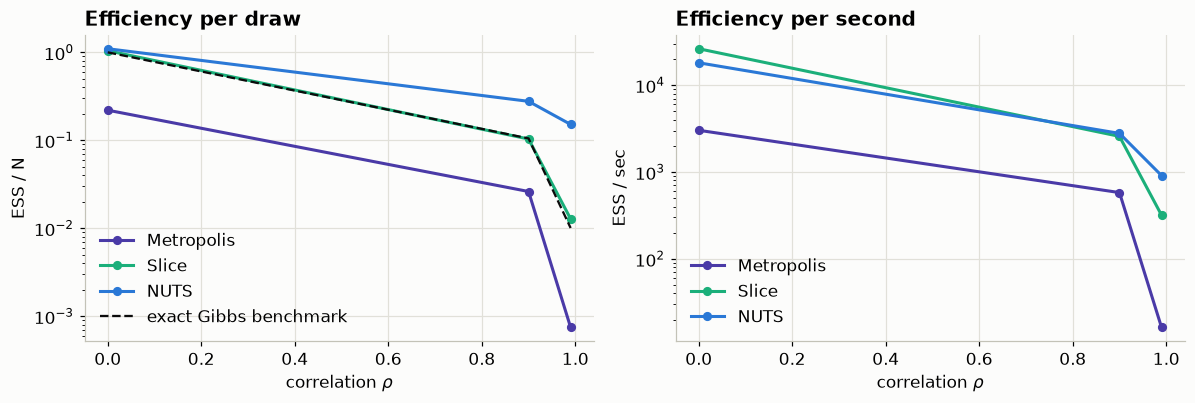

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

for name, (_, colour) in SAMPLERS.items():
    sub = table[table.sampler == name]
    ax1.plot(sub["rho"], sub["ESS/N"], "o-", color=colour, label=name)
    ax2.plot(sub["rho"], sub["ESS/sec"], "o-", color=colour, label=name)

ax1.plot(RHOS, [(1 - r**2) / (1 + r**2) for r in RHOS], "--",
         color=S.TRUTH, lw=1.5, label="exact Gibbs benchmark")
ax1.set(title="Efficiency per draw", xlabel=r"correlation $\rho$",
        ylabel="ESS / N", yscale="log")
ax1.legend()
ax2.set(title="Efficiency per second", xlabel=r"correlation $\rho$",
        ylabel="ESS / sec", yscale="log")
ax2.legend()
fig.tight_layout()

The ordering is the one we predicted. **Slice** sits close to the exact-Gibbs
benchmark — it really does sample along each axis. **Metropolis falls below
it**, because a random walk inside the conditional is strictly worse than
drawing from it. **NUTS beats the benchmark outright**, and that is the whole
argument for gradient-based sampling: it is not a better axis-aligned method,
it is *not axis-aligned at all*, so the $\rho^2$ ceiling does not apply to it.

The full autocorrelation function makes the same point across all lags. This is
`az.plot_autocorr`, which is driven by the same `.azstats.autocorr` accessor we
tabulated above.

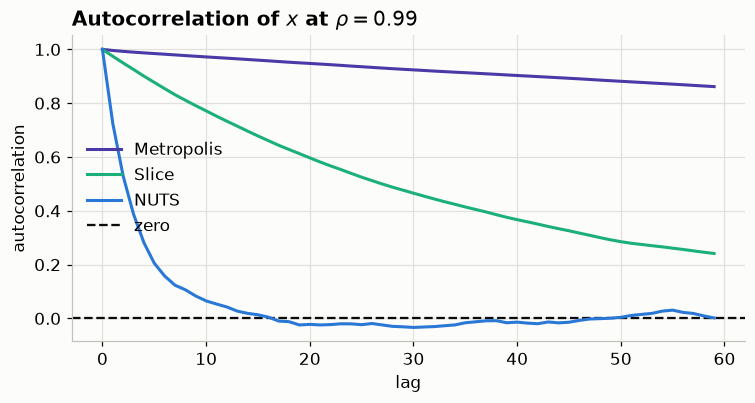

In [6]:
acf_compare = {name: np.asarray(autocorr(results[(0.99, name)])).mean(axis=0)[:60]
               for name in SAMPLERS}

fig, ax = plt.subplots(figsize=(7, 3.8))
for name, (_, colour) in SAMPLERS.items():
    ax.plot(acf_compare[name], color=colour, label=name)
S.truth_line(ax, 0.0, label="zero")
ax.set(title=r"Autocorrelation of $x$ at $\rho = 0.99$", xlabel="lag",
       ylabel="autocorrelation")
ax.legend()
fig.tight_layout()

### A.4 Look at what the chains actually do

Numbers are convincing; pictures are memorable. Here are the first 300 draws
of one chain at $\rho = 0.99$, drawn over the true density.

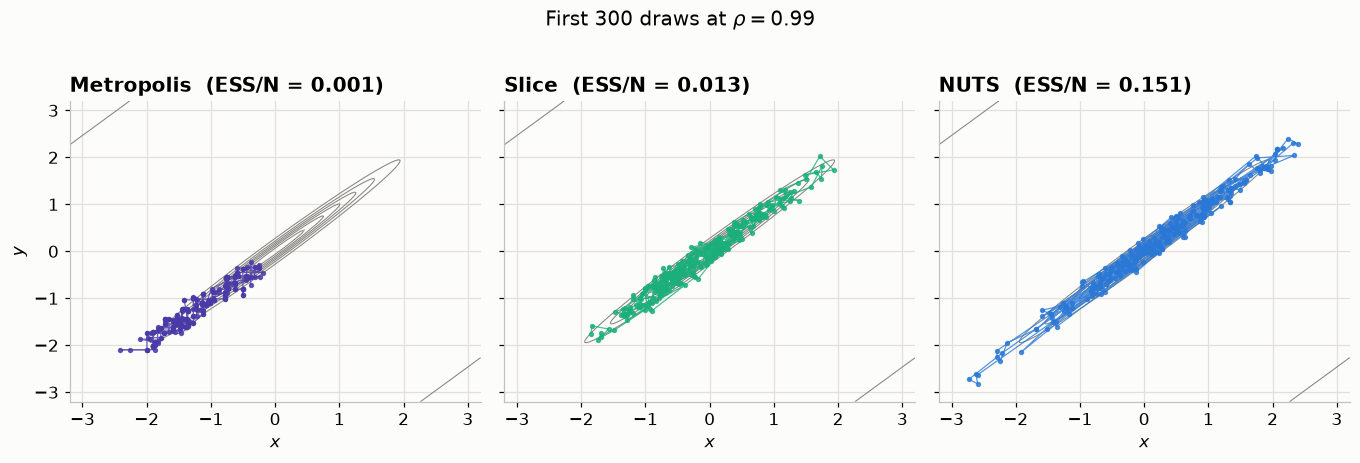

In [7]:
rho = 0.99
gx, gy = np.meshgrid(np.linspace(-3.2, 3.2, 220), np.linspace(-3.2, 3.2, 220))
quad = (gx**2 - 2 * rho * gx * gy + gy**2) / (1 - rho**2)
dens = np.exp(-0.5 * quad)

fig, axes = plt.subplots(1, 3, figsize=(12.5, 4.1), sharex=True, sharey=True)
for ax, (name, (_, colour)) in zip(axes, SAMPLERS.items()):
    post = results[(rho, name)]
    x = post["x"].values[0][:300]
    y = post["y"].values[0][:300]
    ax.contour(gx, gy, dens, levels=6, colors=S.MUTED, linewidths=0.7)
    ax.plot(x, y, "-o", color=colour, lw=0.8, ms=2.5, alpha=0.8)
    ess_n = table[(table.rho == rho) & (table.sampler == name)]["ESS/N"].iloc[0]
    ax.set(title=f"{name}  (ESS/N = {ess_n:.3f})", xlabel="$x$")
axes[0].set_ylabel("$y$")
fig.suptitle("First 300 draws at $\\rho = 0.99$", y=1.02)
fig.tight_layout()

Metropolis inches along the ridge in tiny steps. Slice does better but is
still constrained to move one axis at a time. NUTS traverses the whole ridge
in single transitions.

::: {.callout-note}
## The lesson of Half A
The target was a *perfectly ordinary Gaussian*. No pathology, no heavy tails,
no multimodality. All it had was **correlation** — and that alone was enough
to cost a random-walk sampler 99% of its draws.

Now: what if the correlation is not something you chose, but something your
experiment created?
:::

## Half B — the same problem, wearing a lab coat

### B.1 Two datasets, one model

In the previous session we generated two DDM datasets. Identical model,
identical `a`, `z`, `t`. Only the drift rate differs — and therefore the error
rate.

In [8]:
data_path = pathlib.Path("data/ddm_two_designs.csv")
if not data_path.exists():
    raise FileNotFoundError(
        "Run simulating-cognitive-models.ipynb first — it writes this file."
    )
two = pd.read_csv(data_path)

for design, sub in two.groupby("design", sort=False):
    print(f"{design:9s} n={len(sub)}  error rate {(sub.response == -1).mean():5.1%}  "
          f"mean RT {sub.rt.mean():.3f}s")

balanced  n=800  error rate 22.9%  mean RT 1.579s
extreme   n=800  error rate  0.0%  mean RT 0.705s


> **Poll.** One of these two datasets supports much better parameter
> recovery. Which, and why?
>
> **A.** `extreme` — near-perfect accuracy means less noise.
> **B.** `balanced` — you need errors to identify the parameters.
> **C.** They are equivalent; both come from the same model.
> **D.** `extreme`, but only if you collect more trials.

<details>
<summary>Answer — hold the vote until after B.3</summary>

**B.** Error responses are what let you tell drift rate apart from boundary
separation. A low error rate constrains only the *ratio* of the two, so many
different `(v, a)` pairs predict nearly identical data.

**D** is the seductive wrong answer: more trials does **not** rescue a
zero-error design. Lüken et al. (2025) show recovery still fails at 1200
trials when the error rate is near zero.

</details>

### B.2 A DDM likelihood, by hand

We build the model in raw PyMC using the analytic DDM log-likelihood. Tomorrow
HSSM will do all of this for you in one line — today it is worth seeing that
there is no magic underneath.

In [9]:
from hssm.likelihoods import DDM


def fit_ddm(df, draws=DRAWS, tune=TUNE, chains=CHAINS, step_factory=None,
            seed=RANDOM_SEED):
    """Fit the 4-parameter DDM. Responses must be coded -1/+1.

    `step_factory` is a zero-argument callable, not a step instance: PyMC step
    methods must be constructed *inside* a model context, so building one at the
    top of a loop raises `TypeError: No model on context stack.`
    """
    observed = np.column_stack([df["rt"].to_numpy(), df["response"].to_numpy()])
    with pm.Model():
        v = pm.Normal("v", 0.0, 3.0)
        a = pm.HalfNormal("a", 2.0)
        z = pm.Beta("z", 5.0, 5.0)
        t = pm.HalfNormal("t", 0.5)
        DDM("obs", v=v, a=a, z=z, t=t, observed=observed)
        kw = dict(draws=draws, tune=tune, chains=chains, cores=1,
                  progressbar=False, random_seed=seed)
        t0 = time.time()
        idata = pm.sample(step=step_factory(), **kw) if step_factory is not None \
            else pm.sample(nuts_sampler="pymc", **kw)
        wall = time.time() - t0
    return idata, wall


TRUE = {"v_balanced": 0.5, "v_extreme": 3.0, "a": 1.2, "z": 0.5, "t": 0.3}

fits = {}
for design in ["balanced", "extreme"]:
    sub = two[two.design == design]
    idata, wall = fit_ddm(sub)
    fits[design] = idata
    post = idata.posterior.dataset
    vv, aa = post["v"].values.ravel(), post["a"].values.ravel()
    print(f"{design:9s} {wall:5.1f}s  "
          f"v {vv.mean():5.2f} +/- {vv.std():.2f} (true {TRUE['v_' + design]})   "
          f"a {aa.mean():5.2f} +/- {aa.std():.2f} (true 1.2)   "
          f"corr(v,a) = {np.corrcoef(vv, aa)[0, 1]:+.3f}")

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (4 chains in 1 job)


NUTS: [v, a, z, t]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 15 seconds.


Initializing NUTS using jitter+adapt_diag...


balanced   15.1s  v  0.48 +/- 0.04 (true 0.5)   a  1.19 +/- 0.02 (true 1.2)   corr(v,a) = +0.198


Sequential sampling (4 chains in 1 job)


NUTS: [v, a, z, t]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 63 seconds.


extreme    63.9s  v  2.88 +/- 0.13 (true 3.0)   a  1.66 +/- 0.48 (true 1.2)   corr(v,a) = +0.074


### B.3 What actually broke

`v` is recovered in both designs. `a` is not. Look at how much the posterior
for `a` widens, and — more tellingly — *where it goes*.

In [10]:
prior_a_mean = 2.0 * np.sqrt(2.0 / np.pi)      # mean of HalfNormal(sigma=2)

summary = []
for design in ["balanced", "extreme"]:
    post = fits[design].posterior.dataset
    vv, aa = post["v"].values.ravel(), post["a"].values.ravel()
    summary.append({
        "design": design,
        "error rate": (two[two.design == design].response == -1).mean(),
        "sd(v)": vv.std(), "sd(a)": aa.std(),
        "a_hat": aa.mean(), "corr(v,a)": np.corrcoef(vv, aa)[0, 1],
    })
summary = pd.DataFrame(summary)
print(summary.to_string(index=False, float_format=lambda x: f"{x:8.3f}"))
print(f"\ntrue a = {TRUE['a']}      prior mean of a = {prior_a_mean:.3f}")

  design  error rate    sd(v)    sd(a)    a_hat  corr(v,a)
balanced       0.229    0.040    0.022    1.188      0.198
 extreme       0.000    0.131    0.482    1.662      0.074

true a = 1.2      prior mean of a = 1.596


Read the last two columns together. In the extreme design the posterior for
`a` is roughly an order of magnitude wider **and** its centre has migrated
away from the true 1.2 toward the mean of its own prior.

That is the signature of a parameter the data has stopped speaking about: the
posterior falls back to the prior. Plot it directly.

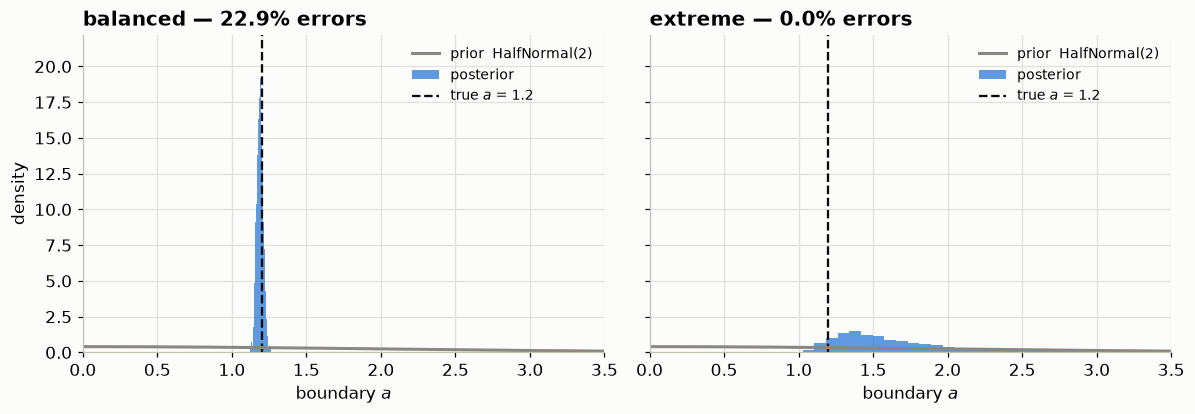

In [11]:
a_grid = np.linspace(0.0, 3.5, 400)
prior_pdf = np.sqrt(2 / np.pi) / 2.0 * np.exp(-(a_grid**2) / (2 * 2.0**2))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharex=True, sharey=True)
for ax, design in zip(axes, ["balanced", "extreme"]):
    aa = fits[design].posterior.dataset["a"].values.ravel()
    ax.plot(a_grid, prior_pdf, "-", color=S.MUTED, lw=2, label="prior  HalfNormal(2)")
    ax.hist(aa, bins=60, density=True, color=S.PRIMARY, alpha=0.75, label="posterior")
    S.truth_line(ax, TRUE["a"], axis="x", label="true $a$ = 1.2")
    err = (two[two.design == design].response == -1).mean()
    ax.set(title=f"{design} — {err:.1%} errors", xlabel="boundary $a$", xlim=(0, 3.5))
    ax.legend(loc="upper right", fontsize=9)
axes[0].set_ylabel("density")
fig.tight_layout()

On the left the posterior is a narrow spike, far tighter than the prior and
sitting on the truth — the data determined `a`. On the right it has spread out
toward the prior and drifted off the true value. **The experiment stopped
measuring `a`.**

### And the joint

There is a positive `v`–`a` tilt, and it is worth looking at, but be careful
about how strong you claim it is.

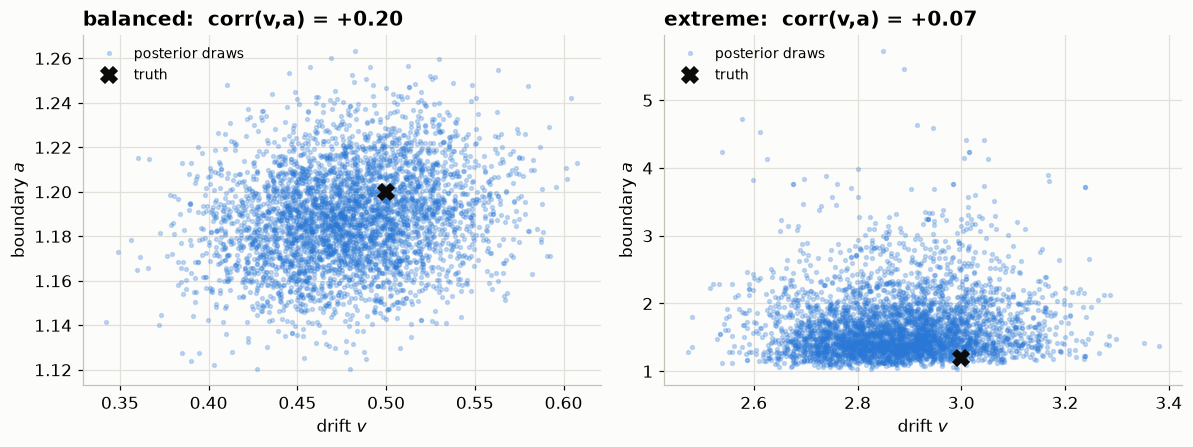

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, design in zip(axes, ["balanced", "extreme"]):
    post = fits[design].posterior.dataset
    vv, aa = post["v"].values.ravel(), post["a"].values.ravel()
    r = np.corrcoef(vv, aa)[0, 1]
    ax.plot(vv, aa, "o", color=S.PRIMARY, ms=2.5, alpha=0.25, ls="none",
            label="posterior draws")
    S.truth_point(ax, TRUE[f"v_{design}"], TRUE["a"])
    ax.set(title=f"{design}:  corr(v,a) = {r:+.2f}",
           xlabel="drift $v$", ylabel="boundary $a$")
    ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()

::: {.callout-note}
## An honest note about how big this trade-off is
Lüken et al. (2025) report within-posterior `a`–`v` correlations approaching
**1** at near-zero error rates. In the plain 4-parameter DDM fitted here the
correlation stays moderate — the collapse shows up as **width and prior
reversion**, not as a near-degenerate ridge.

The reason is worth knowing. Choice proportion identifies the product $v\cdot a$;
with no errors that constraint is gone. But the **shape** of the RT
distribution also carries information about $v \cdot a$, and in the plain DDM
that shape is clean enough to partly stand in. Add across-trial variability —
the parameters people include to make the model realistic — and that second
source of information gets absorbed too, at which point the correlation really
does head for 1.

The moral is the same either way, and it generalises: **the parameters you add
for realism are the ones that consume your identifiability.**
:::

::: {.callout-important}
## Always look at more than the point estimate
Nothing above is visible in a posterior mean. `v` looked fine in both designs.
You need the **width**, the **prior** to compare it against, and the **joint**.
:::

### B.4 What the ridge does to a sampler

Half A told us what to expect from a strongly correlated posterior. Let us
check that the prediction transfers.

In [13]:
comp = []
for design in ["balanced", "extreme"]:
    sub = two[two.design == design]
    for name, factory in [("NUTS", None), ("Metropolis", lambda: pm.Metropolis())]:
        idata, wall = fit_ddm(sub, draws=DRAWS_CMP, tune=TUNE_CMP,
                              chains=2, step_factory=factory)
        ess = float(az.ess(idata, var_names=["v"]).v)
        n = idata.posterior.dataset["v"].values.size
        comp.append({"design": design, "sampler": name, "ESS(v)": ess,
                     "ESS/N": ess / n, "sec": wall, "ESS/sec": ess / wall})

comp = pd.DataFrame(comp)
print(comp.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

Initializing NUTS using jitter+adapt_diag...


Sequential sampling (2 chains in 1 job)


NUTS: [v, a, z, t]


Sampling 2 chains for 1_000 tune and 1_500 draw iterations (2_000 + 3_000 draws total) took 9 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


...

Sampling 2 chains for 1_000 tune and 1_500 draw iterations (2_000 + 3_000 draws total) took 3 seconds.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


  design    sampler   ESS(v)    ESS/N      sec  ESS/sec
balanced       NUTS 1947.847    0.649    9.500  205.041
balanced Metropolis  160.478    0.053    4.899   32.757
 extreme       NUTS  812.080    0.271   40.152   20.225
 extreme Metropolis    9.015    0.003    3.513    2.566


### Exercise

We have watched `a` fall apart. **Predict, before you compute:** rank `a`, `z`
and `t` by how much each one's posterior widens between the balanced and the
extreme design.

Then measure it — compare `sd` for each parameter across the two fits.

In [14]:
widths = []
for design in ["balanced", "extreme"]:
    post = fits[design].posterior.dataset
    widths.append({"design": design,
                   **{f"sd({k})": post[k].values.std() for k in ["a", "z", "t"]}})
widths = pd.DataFrame(widths)
print(widths.to_string(index=False, float_format=lambda x: f"{x:7.4f}"))
print("\nwidening factor, extreme / balanced:")
for k in ["a", "z", "t"]:
    lo, hi = widths[f"sd({k})"]
    print(f"   {k}: {hi / lo:5.1f}x")

  design   sd(a)   sd(z)   sd(t)
balanced  0.0216  0.0133  0.0143
 extreme  0.4817  0.0843  0.0140

widening factor, extreme / balanced:
   a:  22.3x
   z:   6.3x
   t:   1.0x


<details>
<summary>What this shows, and why it is not the tidy story</summary>

The damage is **graded**, not all-or-nothing:

| parameter | widening | posterior mean (true) |
|---|---|---|
| `a` | ~22x | 1.19 → 1.66 (1.2) |
| `z` | ~6x | 0.52 → 0.63 (0.5) |
| `t` | **~1x** | 0.31 → 0.30 (0.3) |

**`t` is completely untouched** — the same posterior width in both designs.
This is the result people most often get backwards: non-decision time *feels*
like the flimsiest parameter and is in fact the most robust here, because it
is pinned by the **leading edge** of the RT distribution, and extreme accuracy
does not erase the leading edge.

**`z` is not robust**, though it degrades far less than `a`. With almost every
response on one boundary, there is little left to identify a start-point bias
from, so `z` drifts toward the upper boundary. Lüken et al. group `z` with
`t0` as well recovered; at least in this 4-parameter setup, `z` sits clearly
between the two extremes rather than with `t`.

Worth checking yourself: `corr(a, t)` is about **-0.60** in the balanced
design and only **-0.09** in the extreme one. The `a`–`t` trade-off gets
*weaker*, not stronger — because in the extreme design `a` is barely
constrained by anything, so it has stopped trading off against `t` in
particular.

</details>

## Synthesis

Half A and Half B are the same phenomenon:

| | where the difficulty came from | what breaks | what you would have missed |
|---|---|---|---|
| **A** | we chose $\rho$ | sampler efficiency | acceptance rate looked *great* |
| **B** | the experiment produced ~0% errors | identifiability of `a` | the posterior mean of `v` looked fine |

In both cases the posterior is *badly conditioned*: there is a direction in
parameter space along which the data says almost nothing. A random-walk
sampler crawls along it; a gradient sampler traverses it but **cannot invent
information that is not there**. No sampler, however good, rescues Half B —
that damage was done when the experiment was designed.

**The design lesson**, from Lüken et al. (2025), *Psychonomic Bulletin &
Review* 32(3):1411–1424: aim for error rates between **15% and 35%**. Below
15% at small trial counts, `v` and `a` stop being separately identifiable —
and collecting more trials does not fix it. Manipulating response caution
(speed vs accuracy instructions) buys more identifiability than manipulating
difficulty.

The counterintuitive headline worth repeating: **high accuracy is bad data for
parameter estimation.**

::: {.callout-note}
## Tomorrow
Both of today's difficulties came from correlation that is roughly the *same
everywhere* in parameter space. Hierarchical models introduce a nastier
relative: curvature that **changes as you move**, so no single step size works
anywhere. That is the funnel, and it is Day 3 at 11:00.
:::